# Balancing Heat: A Performance Comparison of TEGs and Cooling Strategies for Solar PV Panels

Date: 15 May 2025

- Name: Lee Ki-Hoon
- University ID: 3040760060
- Email: kihoon_lee@berkeley.edu

-------

## Summary and Problem Statement

Photovoltaic (PV) performance is highly sensitive to both temperature and solar irradiance—factors that vary by location. **Bath**, UK, receives some of the lowest solar radiation in Europe, making thermal strategies less impactful. **Berkeley**, California, by contrast, experiences high irradiance but also significant panel overheating. **Seoul**, South Korea, lies between the two, with distinct seasonal variability. The three locations mentioined above are cities that I have lived in, which has sparked my curiosity on how drastically PV power generation strategies might differ depending on climate.

This project investigates how best to handle excess heat in PV systems across these climates. Should the heat be **harvested using thermoelectric generators (TEGs)**, or **removed using active cooling systems** to maintain optimal PV efficiency?

To answer this, we simulate and compare both strategies using typical meteorological year (TMY) data from all three cities. To save time and because all of the cities sit above the equator in the northern hemisphere, each strategy is evaluated on three representative days:
- **Winter Solstice**, with the lowest solar irradiance (Dec 21)
- **Equinox**, with moderate conditions (Mar 20)
- **Summer Solstice**, with peak irradiance and thermal stress (Jun 21)

The core goal is to determine which approach—TEG or cooling—delivers a **greater net energy benefit**, and how that tradeoff shifts with location and season.


-------

## Background Information

As solar photovoltaic (PV) systems continue to scale globally, improving energy yield under real-world conditions has become critical. One key limitation is that PV panels lose efficiency as they heat up, especially in high-irradiance environments. Managing this excess heat is an open design challenge, with two promising but contrasting strategies emerging: **thermoelectric generators (TEGs)** and **active cooling systems**.

### Thermoelectric Generators (TEGs)
TEGs operate based on the Seebeck effect—generating electricity from temperature gradients across specially engineered semiconductors. When mounted on the rear of PV panels, they can recover a portion of the thermal energy otherwise lost to the environment. Although their efficiency is relatively low (typically below 10%), they offer a passive solution that does not consume additional energy.

### Active Cooling
In contrast, active cooling systems improve PV performance by dissipating heat—via air flow, water circulation, or thermoelectric cooling modules. This keeps panel temperatures closer to their rated operating condition, thereby increasing electrical output. However, this approach comes with a tradeoff: **it consumes energy**, which can reduce or even negate the performance gains.

This project compares the net power output from each strategy across three cities with different solar profiles—**Bath**, **Seoul**, and **Berkeley**—using real weather data. By simulating system behavior on three key days of the year (solstices and equinox), we aim to understand how environmental factors shape the viability of each approach. This analysis can guide location-specific design decisions for maximizing the overall energy benefit of PV installations.


-------

## Setup for the Photovoltaic Farm



In [1]:
pip install pvlib

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pvlib in c:\users\kihoo\appdata\local\programs\python\python312\lib\site-packages (0.12.0)




[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pvlib
import pandas as pd
import matplotlib.pyplot as plt

# Locations: 
locations = {
    'Bath': (51.38, -2.36, 'Etc/GMT+0'),
    'Seoul': (37.56, 126.97, 'Asia/Seoul'),
    'Berkeley': (37.87, -122.27, 'Etc/GMT+8')
}

# Dates to plot
dates = {
    'Winter Solstice': '12-21',
    'Equinox': '03-20',
    'Summer Solstice': '06-21'
}

# Download TMY weather data
weather_data = {}
for name, (lat, lon, tz) in locations.items():
    raw_weather = pvlib.iotools.get_pvgis_tmy(lat, lon)
    weather = raw_weather[0]
    weather.index.name = "utc_time"
    if weather.index.tz is None:
        weather = weather.tz_localize("UTC").tz_convert(tz)
    else:
        weather = weather.tz_convert(tz)
    weather_data[name] = weather

# Shared constants
gcr = 0.4
modules_per_string = 10
total_strings = 2800
A_panel = 1.65 * 0.992  # m²

# Load module and temp model
sandia_modules = pvlib.pvsystem.retrieve_sam('sandiamod')
module = sandia_modules['Canadian_Solar_CS5P_220M___2009_']
temp_params = pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']


-----

## Seasonal Variation in Global Horizontal Irradiance (GHI)

To evaluate how solar irradiance varies seasonally and geographically, we begin by plotting the **Global Horizontal Irradiance (GHI)** across three cities—**Bath**, **Seoul**, and **Berkeley**—on the three key days.

For each city, weather data from a typical meteorological year (TMY) was used to extract GHI values on these specific dates. To enable a fair comparison, all timestamps were normalized to the same year. The resulting plots show hourly GHI values throughout each day, providing insight into the **intensity and duration of solar exposure** for each location.


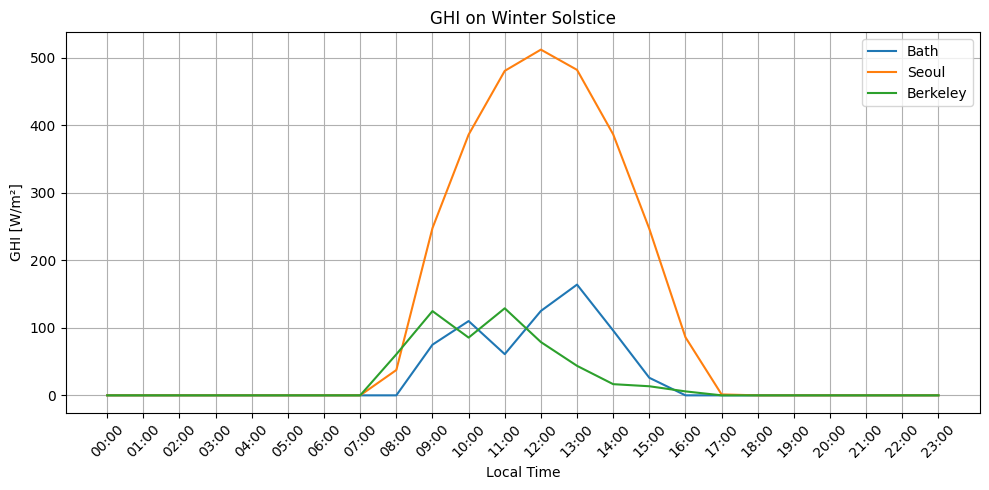

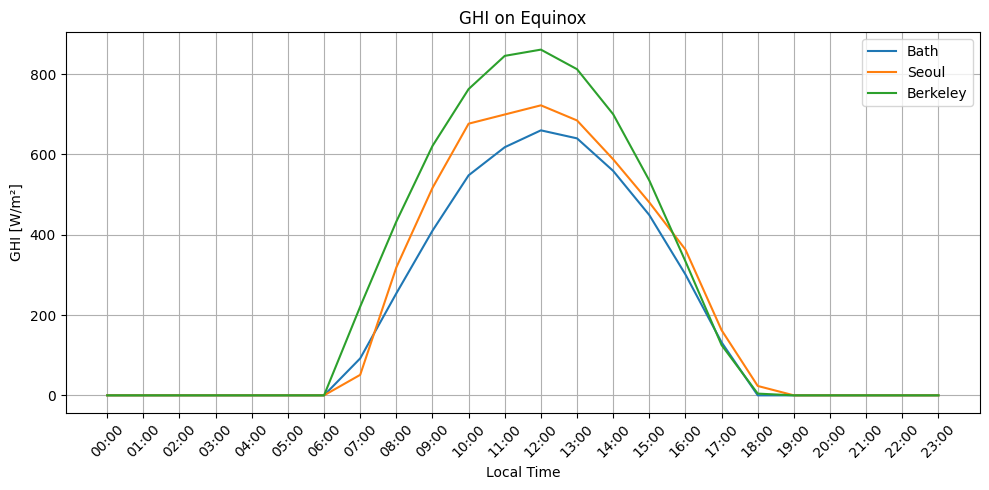

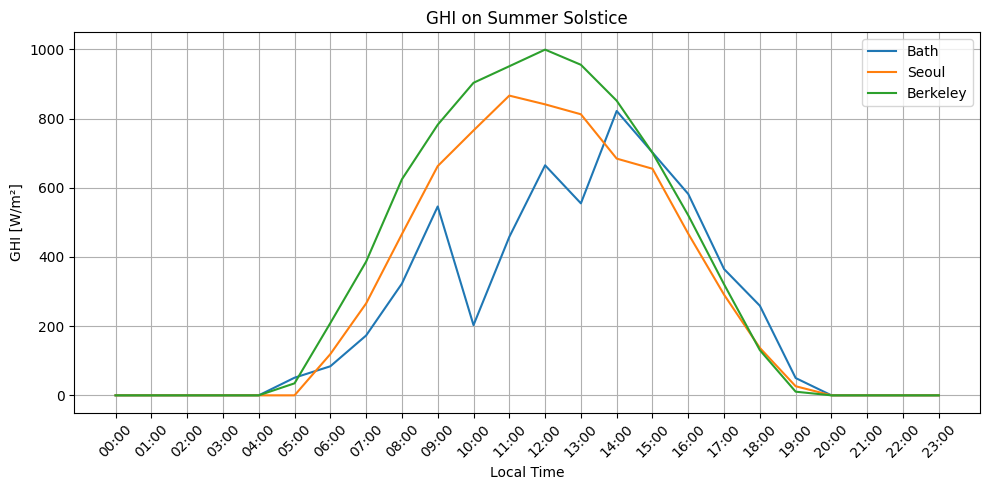

In [3]:
for season, date_str in dates.items():
    plt.figure(figsize=(10, 5))
    for name, data in weather_data.items():
        df = data.copy()
        df.index = df.index.map(lambda x: x.replace(year=2000))
        day_data = df[df.index.strftime('%m-%d') == date_str]
        plt.plot(day_data.index.strftime('%H:%M'), day_data['ghi'], label=name)

    plt.title(f"GHI on {season}")
    plt.xlabel("Local Time")
    plt.ylabel("GHI [W/m²]")
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

These irradiance profiles form the foundation for later energy production simulations. Locations like **Berkeley**, with a broad and high GHI curve during the summer, present strong opportunities for energy harvesting—but also face significant thermal challenges. In contrast, **Bath** exhibits low and narrow irradiance profiles, limiting both the solar energy available and the thermal load on PV panels. Additionally, in typical UK fashion there is a large fluctuation in solar irradiance most likely due to cloud cover, which the country is notoriously known for. Lastly, **Seoul** shows intermediate behavior with a more pronounced seasonal swing.

---

## Simulating Daily PV Power Output

To evaluate how much energy a solar photovoltaic system can produce under real-world conditions, we simulate the PV output across an entire year for each city using irradiance and temperature data.

This simulation includes the following key steps:

1. **Solar Geometry and Tracking:**  
   For each location, the sun’s position (zenith and azimuth angles) is computed using local weather and geographic data. A single-axis tracking system is modeled to follow the sun and adjust the panel orientation, minimizing the angle of incidence and maximizing energy capture.

2. **Plane-of-Array (POA) Irradiance and Optical Effects:**  
   Using the Hay-Davies model, we calculate total irradiance on the tilted panel surface. This includes direct, diffuse, and reflected components. The effective irradiance—what actually reaches the PV cell—is then computed by accounting for optical losses due to air mass and panel angle.

3. **Cell Temperature Estimation:**  
   Since temperature affects PV efficiency, the cell temperature is calculated using the SAPM (Sandia Array Performance Model), which accounts for irradiance, ambient temperature, and wind speed.

4. **DC Power Output and Daily Energy:**  
   With irradiance and temperature data, we simulate the DC power output using a standard SAPM PV module. Power is calculated at maximum power point (MPP), scaled to system size, and aggregated to compute daily energy values.

The resulting plots show how PV production varies across the year for each city, highlighting the impact of both irradiance and temperature on energy yield.


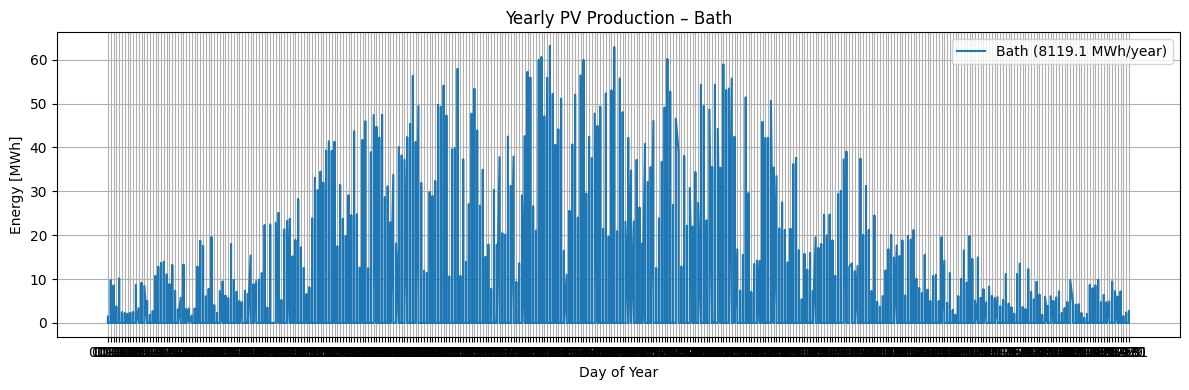

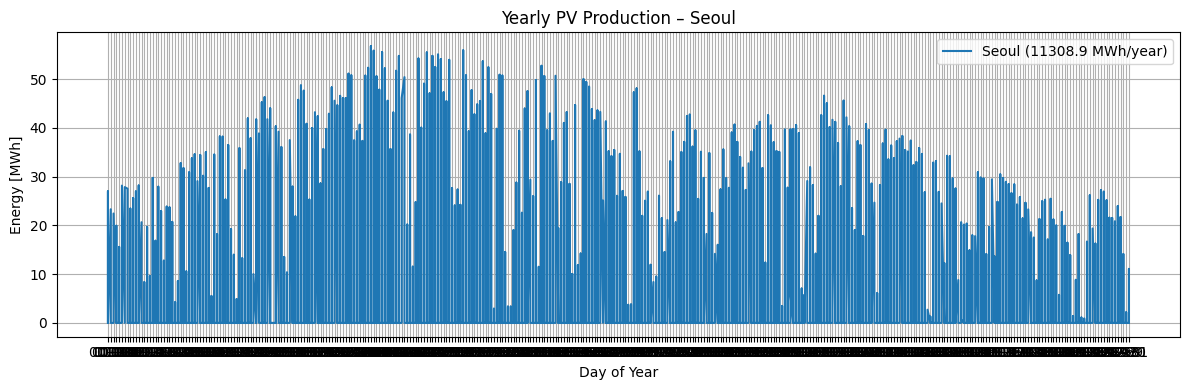

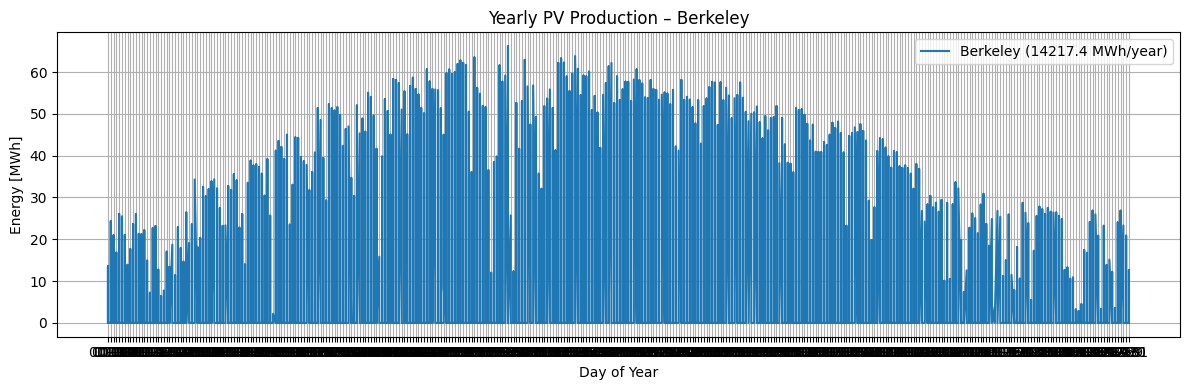

In [4]:
# Initialize storage
daily_energy_all = {}
annual_totals = {}
irr_all = {}
cell_temp_all = {}
pv_energy_kWh = {}
results = []

for name, weather in weather_data.items():
    lat, lon, tz = locations[name]
    alt = weather.attrs.get("altitude", 50)

    solpos = pvlib.solarposition.get_solarposition(
        time=weather.index,
        latitude=lat,
        longitude=lon,
        altitude=alt,
        temperature=weather["temp_air"],
        pressure=weather["pressure"],
    )

    tracking = pvlib.tracking.singleaxis(
        apparent_zenith=solpos['apparent_zenith'],
        apparent_azimuth=solpos['azimuth'],
        axis_tilt=0,
        axis_azimuth=180,
        max_angle=60,
        backtrack=True,
        gcr=gcr
    )

    tilt = tracking['surface_tilt'].fillna(0)
    azimuth = tracking['surface_azimuth'].fillna(0)

    dni_extra = pvlib.irradiance.get_extra_radiation(weather.index)
    airmass = pvlib.atmosphere.get_relative_airmass(solpos['apparent_zenith'])
    pressure = pvlib.atmosphere.alt2pres(alt)
    am_abs = pvlib.atmosphere.get_absolute_airmass(airmass, pressure)

    aoi = pvlib.irradiance.aoi(tilt, azimuth, solpos["apparent_zenith"], solpos["azimuth"])

    irr = pvlib.irradiance.get_total_irradiance(
        tilt, azimuth, solpos['apparent_zenith'], solpos['azimuth'],
        weather['dni'], weather['ghi'], weather['dhi'], dni_extra=dni_extra,
        model='haydavies'
    )
    irr_all[name] = irr

    cell_temp = pvlib.temperature.sapm_cell(
        irr['poa_global'], weather["temp_air"], weather["wind_speed"], **temp_params
    )
    cell_temp_all[name] = cell_temp

    eff_irr = pvlib.pvsystem.sapm_effective_irradiance(
        irr['poa_direct'], irr['poa_diffuse'], am_abs, aoi, module
    )

    dc = pvlib.pvsystem.sapm(eff_irr, cell_temp, module)
    dc_power = dc['p_mp'] * modules_per_string * total_strings / 1e6  # MW

    daily_energy = dc_power.clip(lower=0).resample('h').mean().resample('D').sum()
    daily_energy.index = daily_energy.index.strftime('%m-%d')
    daily_energy_all[name] = daily_energy.sort_index()
    annual_totals[name] = dc_power.sum()

    plt.figure(figsize=(12, 4))
    plt.plot(daily_energy_all[name], label=f"{name} ({annual_totals[name]:.1f} MWh/year)")
    plt.title(f"Yearly PV Production – {name}")
    plt.xlabel("Day of Year")
    plt.ylabel("Energy [MWh]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
print("\nPV Output on Key Dates (kWh):\n")

for name in locations:
    daily = daily_energy_all[name]  # Index is 'mm-dd', with many duplicates

    for label, date_str in dates.items():
        try:
            values = daily.loc[date_str]
            total_energy_kWh = values.sum() * 1000  # MWh → kWh
            pv_energy_kWh[(name, label)] = total_energy_kWh
            print(f"{name} – {label}: {total_energy_kWh:.1f} kWh")
        except KeyError:
            print(f"{name} – {label}: Not found")



PV Output on Key Dates (kWh):

Bath – Winter Solstice: 4673.5 kWh
Bath – Equinox: 41357.1 kWh
Bath – Summer Solstice: 42380.9 kWh
Seoul – Winter Solstice: 27230.4 kWh
Seoul – Equinox: 42898.4 kWh
Seoul – Summer Solstice: 48457.4 kWh
Berkeley – Winter Solstice: 3252.2 kWh
Berkeley – Equinox: 52273.8 kWh
Berkeley – Summer Solstice: 60103.9 kWh


## Yearly PV Production and Key Day Output

The total simulated yearly PV energy production for each city was:

- **Bath:** 8,119.1 MWh  
- **Seoul:** 11,308.9 MWh  
- **Berkeley:** 14,217.4 MWh  

These results reflect clear regional trends. **Bath** produces significantly less energy over the year compared to **Seoul** and **Berkeley**, largely due to its higher latitude and more frequent cloud cover. However, Bath still shows strong output on equinox and summer solstice — indicating that while its solar potential is limited, it can perform well under optimal conditions.

**Seoul** sits in the middle, with a balance of strong seasonal variation and high irradiance during spring and summer. Its equinox and summer day outputs are relatively close, reflecting a strong seasonal transition and consistent performance during the warmer months.

**Berkeley** leads in total annual production. While its winter solstice output is the lowest of the three cities, its equinox and summer outputs are the highest — driven by a favorable solar climate with mild temperatures and clear skies, especially in late spring and summer.

Overall, the comparison shows how geographic and climatic factors influence both daily and annual PV yield — with **Berkeley excelling annually**, **Seoul showing consistent seasonal performance**, and **Bath performing well under peak conditions despite a lower yearly total**.

---
    
## PV Cell Temperature on Key Solar Dates

In this section, we examine **PV cell temperature profiles** for each city on three key days:

Using the Sandia cell temperature model, we estimated PV cell temperatures throughout each day, based on ambient air temperature, wind speed, and incident irradiance. The results are plotted as a function of time, showing how cell temperatures rise and fall with the solar cycle.

These plots reveal not only the thermal behavior of each location, but also highlight differences in thermal load across climates. For example, **Berkeley** may experience higher midday temperatures despite similar irradiance levels due to lower wind speeds or higher ambient temperatures, while **Bath** shows cool profiles but relatively unstable temperatures again due to cloud coverage.


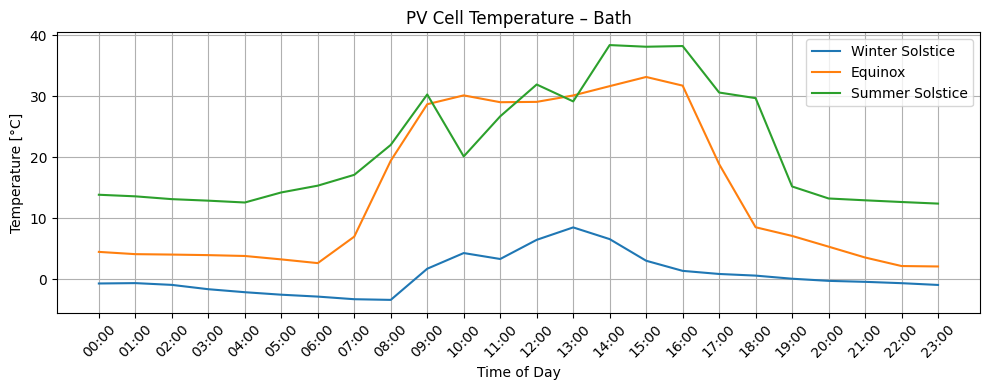

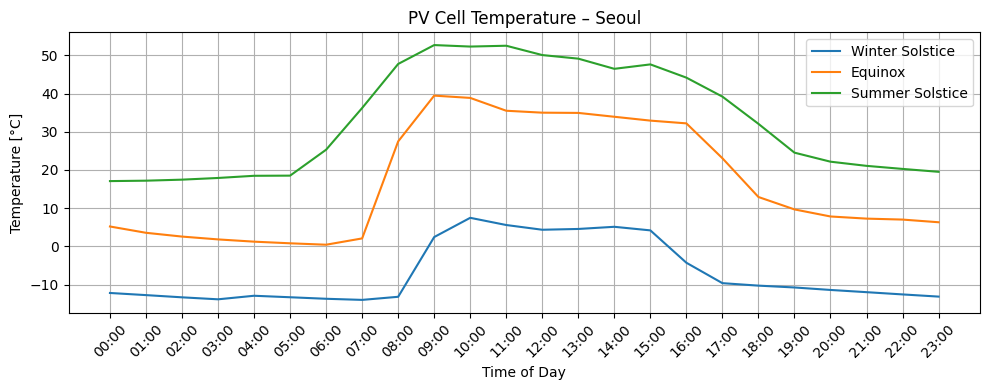

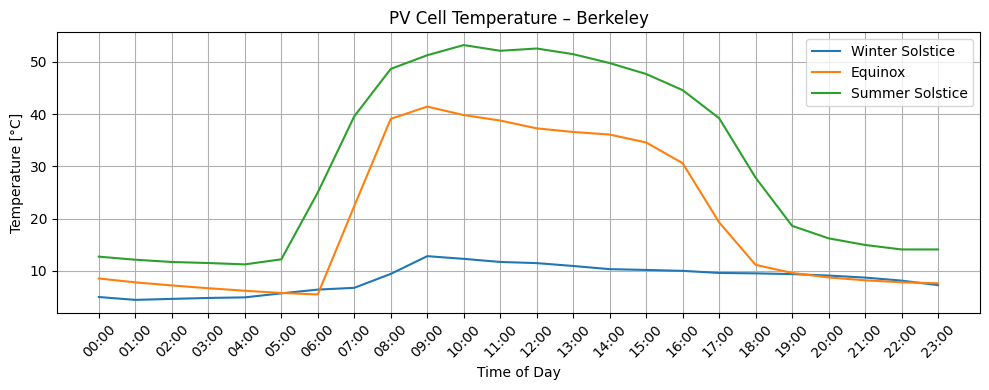

In [6]:
for name in locations:
    temp = cell_temp_all[name].copy()
    temp.index = temp.index.map(lambda x: x.replace(year=2000))

    plt.figure(figsize=(10, 4))
    for label, date_str in dates.items():
        day_data = temp[temp.index.strftime('%m-%d') == date_str]
        plt.plot(day_data.index.strftime('%H:%M'), day_data, label=label)

    plt.title(f"PV Cell Temperature – {name}")
    plt.xlabel("Time of Day")
    plt.ylabel("Temperature [°C]")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


---

## Thermoelectric Generator (TEG) Power Output

In this section, we simulate TEG power output for each location on three key dates.

To estimate power output, we compare the PV cell temperature ($T_H$) and ambient air temperature ($T_C$) throughout each day. The TEG efficiency is modeled using the following equation:

$$\eta_\text{max}= \left(\frac{T_H - T_C}{T_H} \right)\left(\frac{\sqrt{1 + Z\bar{T}} - 1}{\sqrt{1 + Z\bar{T}} + T_C/T_H} \right) $$

where:
- $\bar{T}$ is the average of $T_H$ and $T_C$
- $Z$ is the thermoelectric figure of merit:

$$
Z = \frac{S^2 \sigma}{k}
$$

- $S$ is the Seebeck coefficient (V/K)
- $\sigma$ is the electrical conductivity (S/m)
- $k$ is the thermal conductivity (W/m·K)

The **heat flow** into the TEG is calculated as:

$$
\Delta T = (T_H - T_C)
$$

$$
Q = A_{\text{panel}} \cdot h \cdot \Delta T
$$

The **electrical power output per panel** is then:

$$
P_{\text{TEG, per panel}} = \eta_\text{max} \cdot Q
$$

And the **total system power output** is:

$$
P_{\text{TEG, total}} = P_{\text{TEG, per panel}} \cdot N_{\text{strings}} \cdot N_{\text{modules per string}}
$$

These values are computed over each hour of the day and plotted, with total daily energy (in kWh) shown in the legend for each location and date.

### Parameter Selection

To simulate realistic thermoelectric generator (TEG) performance, we selected representative values for the **figure of merit** \( Z \) and the **heat transfer coefficient** \( h \):

- **\( Z = 0.0035 \)**  
  This value represents the **combined material performance** of currently available commercial thermoelectric materials (e.g., Bi$_2$Te$_3$
-based compounds) operating near room temperature. It accounts for the tradeoff between high Seebeck coefficient, electrical conductivity, and low thermal conductivity. While laboratory-scale materials can achieve \( ZT > 1 \), real-world module-level performance is typically lower, especially when contact resistance, thermal losses, and system integration are considered.

- **\( h = 10 \)**  
  This is a **typical convective heat transfer coefficient** for natural convection over flat surfaces in ambient air, such as a solar panel exposed to outdoor conditions. It provides a conservative baseline for estimating the amount of thermal energy available to the TEGs without forced airflow or radiative enhancements.


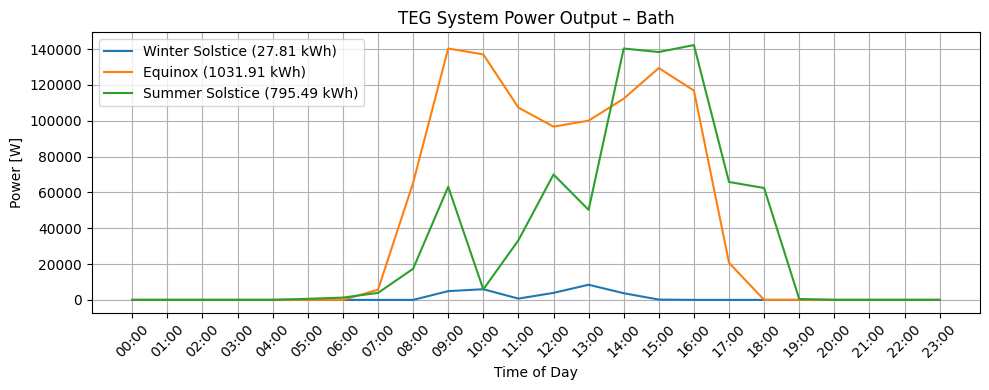

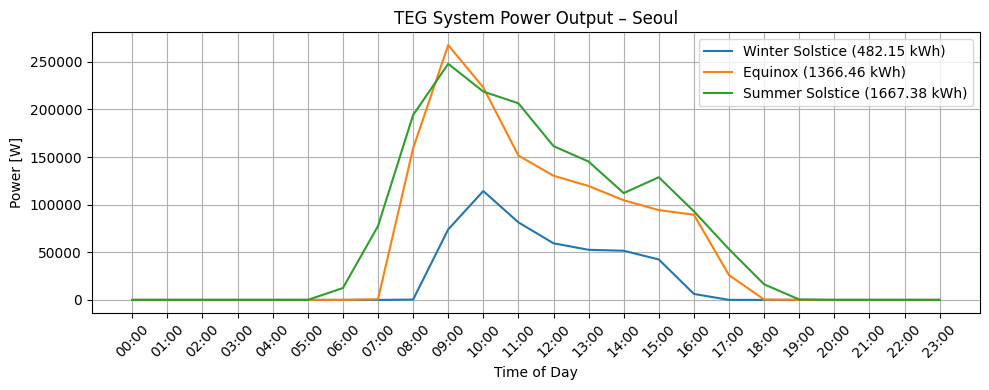

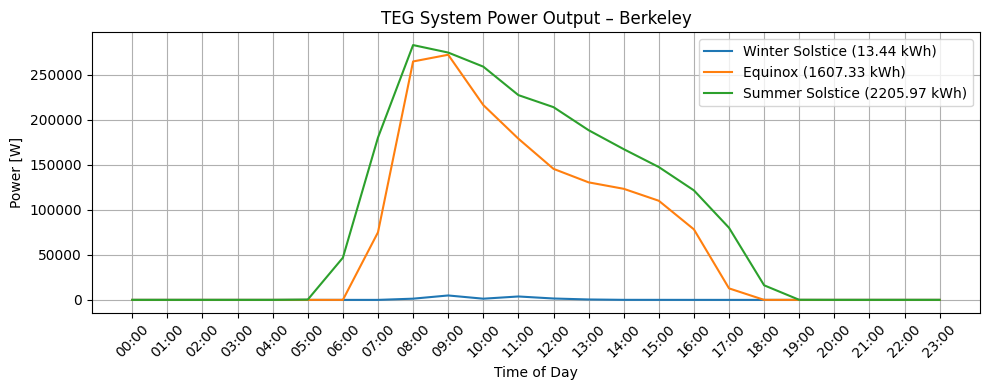

In [7]:
Z = 0.0035
h = 10  # W/m²·K

for name in locations:
    temp_C = cell_temp_all[name].copy()
    temp_C.index = temp_C.index.map(lambda x: x.replace(year=2000))
    air_temp = weather_data[name]["temp_air"].copy()
    air_temp.index = air_temp.index.map(lambda x: x.replace(year=2000))

    plt.figure(figsize=(10, 4))

    for label, date_str in dates.items():
        T_H = temp_C[temp_C.index.strftime('%m-%d') == date_str] + 273.15
        T_C = air_temp[air_temp.index.strftime('%m-%d') == date_str] + 273.15
        T_C = T_C.reindex(T_H.index, method='nearest')

        T_bar = (T_H + T_C) / 2
        sqrt_term = (1 + Z * T_bar) ** 0.5
        eta = ((T_H - T_C) / T_H).clip(lower=0) * ((sqrt_term - 1) / (sqrt_term + (T_C / T_H)))

        delta_T = (T_H - T_C).clip(lower=0)
        Q = A_panel * h * delta_T
        P_teg_per_panel = eta * Q
        P_teg_total = P_teg_per_panel * total_strings * modules_per_string

        E_day_Wh = P_teg_total.sum()

        plt.plot(T_H.index.strftime('%H:%M'), P_teg_total, label=f"{label} ({E_day_Wh/1000:.2f} kWh)")

            # Store TEG energy result for comparison
        results.append({
            "Location": name,
            "Day": label,
            "E_TEG_kWh": E_day_Wh / 1000, 
            "E_PV_Gain_kWh": None,
            "E_Cooling_kWh": None
        })

    plt.title(f"TEG System Power Output – {name}")
    plt.xlabel("Time of Day")
    plt.ylabel("Power [W]")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [8]:
import pandas as pd
from IPython.display import display

# Combine TEG and PV data
summary = {}

for r in results:
    city = r["Location"]
    day = r["Day"]
    key = (city, day)

    if key not in pv_energy_kWh:
        continue  # skip if PV not found for this day

    if city not in summary:
        summary[city] = {}

    summary[city][day] = {
        "TEG": round(r["E_TEG_kWh"], 2),
        "PV": round(pv_energy_kWh[key], 1)
    }

# Format table
rows = []
for city in sorted(summary.keys()):
    try:
        t_w = summary[city]["Winter Solstice"]["TEG"]
        p_w = summary[city]["Winter Solstice"]["PV"]
        t_e = summary[city]["Equinox"]["TEG"]
        p_e = summary[city]["Equinox"]["PV"]
        t_s = summary[city]["Summer Solstice"]["TEG"]
        p_s = summary[city]["Summer Solstice"]["PV"]

        percent_str = f"{round(100 * t_w / p_w, 1)}% / {round(100 * t_e / p_e, 1)}% / {round(100 * t_s / p_s, 1)}%"

        rows.append({
            "City": city,
            "TEG Winter [kWh]": t_w,
            "PV Winter [kWh]": p_w,
            "TEG Equinox [kWh]": t_e,
            "PV Equinox [kWh]": p_e,
            "TEG Summer [kWh]": t_s,
            "PV Summer [kWh]": p_s,
            "TEG % of PV (Winter / Equinox / Summer)": percent_str
        })
    except KeyError:
        print(f"Incomplete data for {city}, skipping...")

# Show table
df = pd.DataFrame(rows)
display(df)


,City,TEG Winter [kWh],PV Winter [kWh],TEG Equinox [kWh],PV Equinox [kWh],TEG Summer [kWh],PV Summer [kWh],TEG % of PV (Winter / Equinox / Summer)
0,Bath,27.81,4673.5,1031.91,41357.1,795.49,42380.9,0.6% / 2.5% / 1.9%
1,Berkeley,13.44,3252.2,1607.33,52273.8,2205.97,60103.9,0.4% / 3.1% / 3.7%
2,Seoul,482.15,27230.4,1366.46,42898.4,1667.38,48457.4,1.8% / 3.2% / 3.4%


### Key Takeaways

- TEG output is **negligible during winter**, which aligns with low PV production across all locations.
- On **equinox and summer days**, TEGs deliver up to **3–4%** of the PV system output in cities like Seoul and Berkeley.
- **Seoul** achieves the best overall performance due to strong temperature gradients and solid irradiance.
- In cooler climates, **TEGs offer a passive and maintenance-free way** to reclaim a small but consistent portion of otherwise wasted heat.

---

## Active Cooling System Power Demand

To evaluate an alternative method for improving PV efficiency, we analyzed the energy cost of **actively cooling** the solar panels to a fixed target temperature of 25°C. 25°C was chosen as the target temperature because it represents the standard test condition (STC) for PV modules, ensuring optimal efficiency and comparability across simulations. When the panel temperature exceeds this threshold, a cooling system removes excess heat through convective heat transfer. All calculations are scaled to a full 28,000-panel system.

The system assumes:

$$
h_{\text{cool}} = 15 \, \text{W/m}^2\cdot\text{K}
$$

$$
T_{\text{target}} = 25^\circ\text{C}
$$

$$
\text{COP} = 3.0
$$

### Cooling Parameter

To assess the **best-case energy cost** of active cooling, we use optimistic yet physically plausible values for the heat transfer coefficient and cooling system efficiency:

$$
h_{\text{cool}} = 5 \, \text{W/m}^2\cdot\text{K}, \quad \text{COP} = 6
$$

- **Heat Transfer Coefficient**:  
A value of 5 W/m²·K represents minimal natural convection, typical of passive environments with little airflow. While such a low coefficient implies limited heat dissipation in reality, we use it here as a conservative baseline to estimate the cooling power required to actively maintain a constant panel temperature of 25°C. This assumption allows us to quantify the upper bound of energy needed for temperature regulation under worst-case thermal conditions.

- **Coefficient of Performance**:  
  A COP of 6 represents a **very efficient active cooling system**, such as a high-performance heat pump or a vapor-compression unit operating under favorable temperature conditions (i.e., a small difference between ambient and target temperatures). While not typical of all real-world installations, this value is **technically achievable** with modern HVAC equipment and allows us to model the **upper limit of system efficiency**.

By using these favorable parameters, we aim to explore the **feasibility ceiling** for active cooling — quantifying the lowest possible energy input required to maintain PV panel temperature at 25°C and comparing it to potential energy gains.

### Cooling Power Calculations

The **temperature difference** driving heat removal is:

$$
\Delta T = (T_{\text{cell}} - T_{\text{target}})
$$

The **heat removed per panel** is:

$$
Q_{\text{per panel}} = h_{\text{cool}} \cdot A_{\text{panel}} \cdot \Delta T
$$

The **cooling power required per panel** is:

$$
P_{\text{cool, per panel}} = \frac{Q_{\text{per panel}}}{\text{COP}}
$$

And the **total cooling power demand** for the system is:

$$
P_{\text{cool, total}} = P_{\text{cool, per panel}} \cdot N_{\text{strings}} \cdot N_{\text{modules per string}}
$$

---

This time-dependent power demand is integrated over the day to compute the **total daily cooling energy consumption (in kWh)** for each location and solar condition.


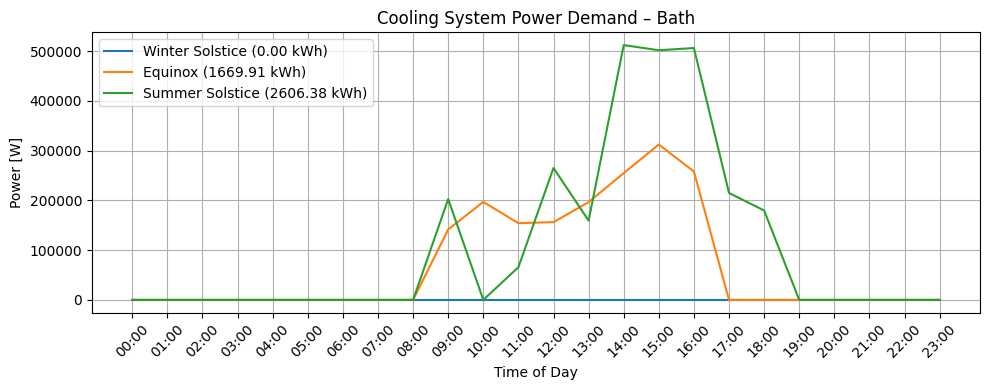

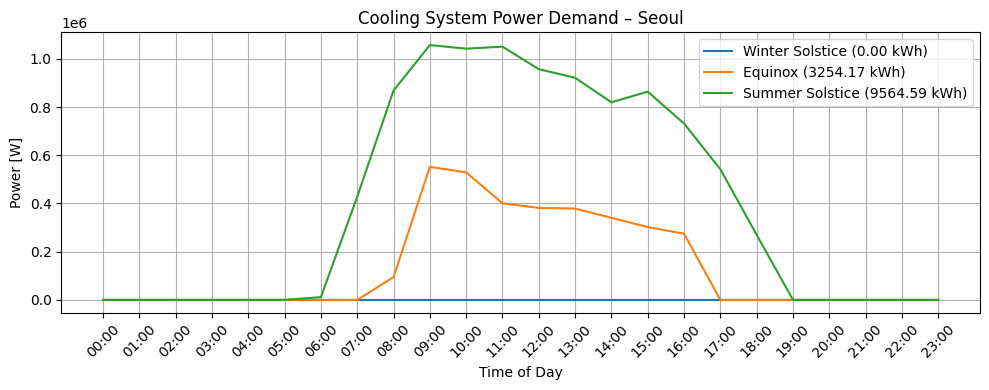

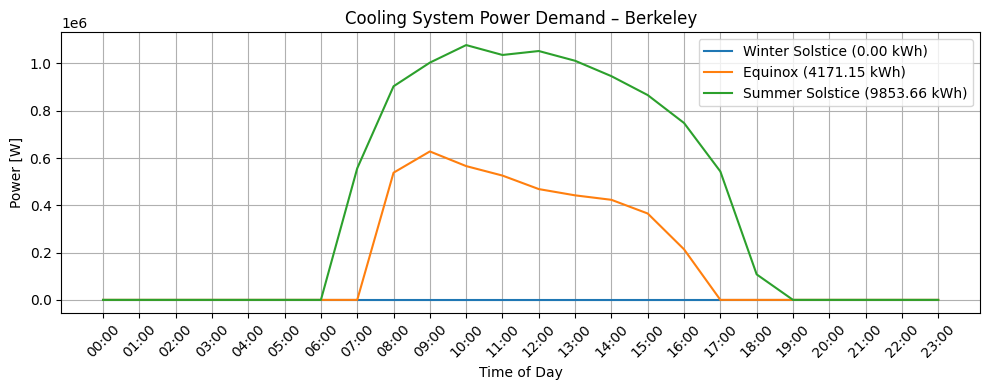

In [9]:
h_cool = 5
COP = 6.0
target_temp = 25

for name in locations:
    temp_C = cell_temp_all[name].copy()
    temp_C.index = temp_C.index.map(lambda x: x.replace(year=2000))

    plt.figure(figsize=(10, 4))

    for label, date_str in dates.items():
        T_cell = temp_C[temp_C.index.strftime('%m-%d') == date_str]
        delta_T = (T_cell - target_temp).clip(lower=0)
        Q_per_panel = A_panel * h_cool * delta_T
        P_cool_per_panel = Q_per_panel / COP
        P_cool_total = P_cool_per_panel * total_strings * modules_per_string

        E_cooling_Wh = P_cool_total.sum()

        plt.plot(T_cell.index.strftime('%H:%M'), P_cool_total, label=f"{label} ({E_cooling_Wh/1000:.2f} kWh)")

            # Store cooling energy for matching entry
        for r in results:
            if r["Location"] == name and r["Day"] == label:
                r["E_Cooling_kWh"] = E_cooling_Wh / 1000


    plt.title(f"Cooling System Power Demand – {name}")
    plt.xlabel("Time of Day")
    plt.ylabel("Power [W]")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()




### Key Observations

- **Cooling is only active when PV cell temperature exceeds 25°C**, which typically excluded all the winter solstice days.
- The **cooling power profile** is strongly time-dependent, peaking during midday.
- **Bath**, being cooler, required minimal cooling energy overall.
- In **Seoul** and **Berkeley**, especially during the **summer solstice**, cooling demands became significant, sometimes consuming thousands of kilo watt-hours to maintain target temperature.

This analysis provides a basis for comparing the **energy cost of cooling** versus the **efficiency gains it enables** — critical for deciding whether active cooling is more viable than passive strategies like TEGs.

---

## PV Energy Gains from Panel Cooling

In this section, we compare PV system performance under two operating conditions:
1. **Actual panel temperatures** calculated from environmental data
2. A **theoretical fixed temperature of 25°C**, representing an ideal active cooling scenario

Using the same irradiance and solar geometry data, we simulate the maximum power output ($P_{mp}$) of the PV system for both cases. This lets us quantify the **extra energy generated** thanks to improved efficiency from cooling.

Only **equinox and summer solstice** are considered, as winter temperatures typically stay below 25°C — meaning active cooling would not be applied.

---



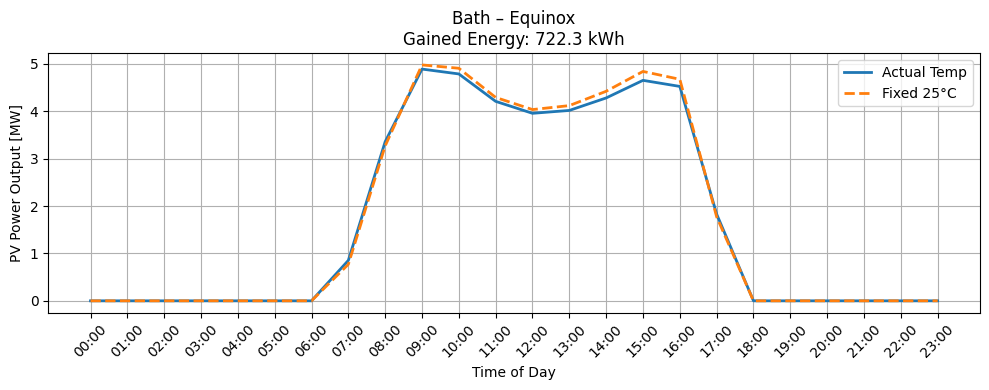

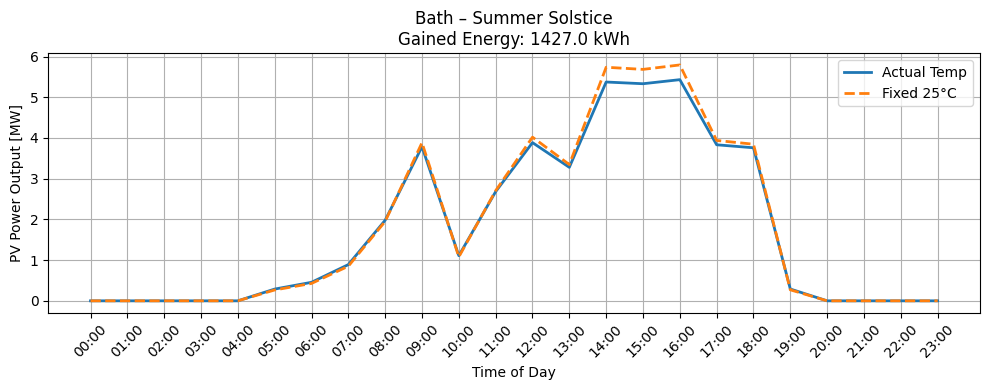

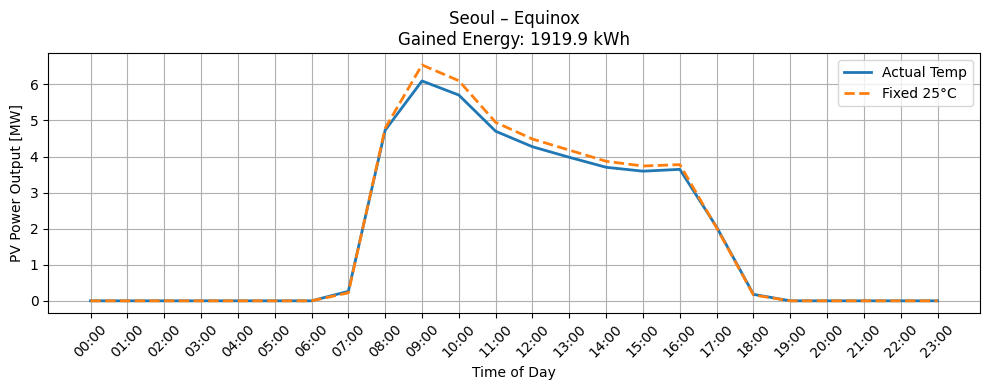

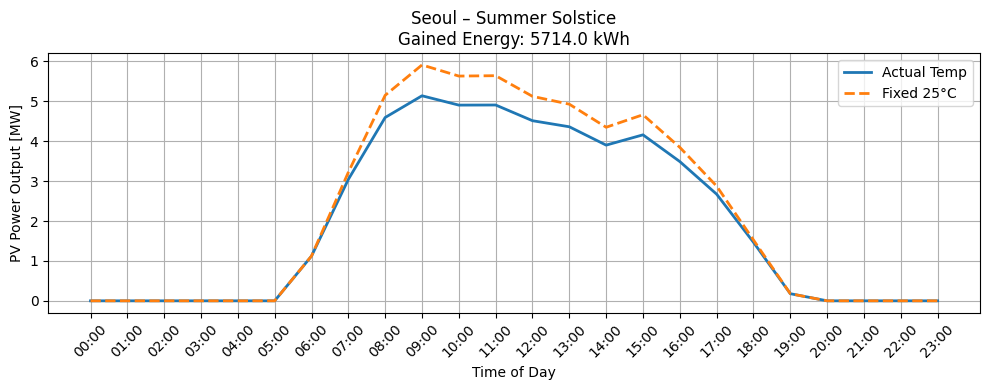

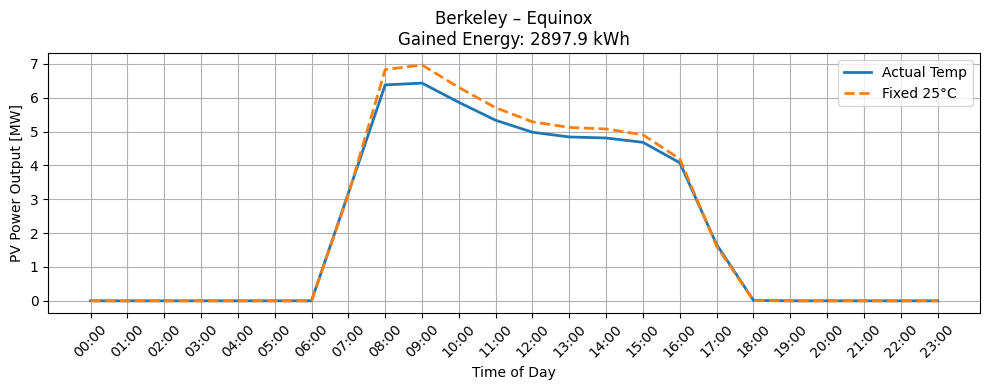

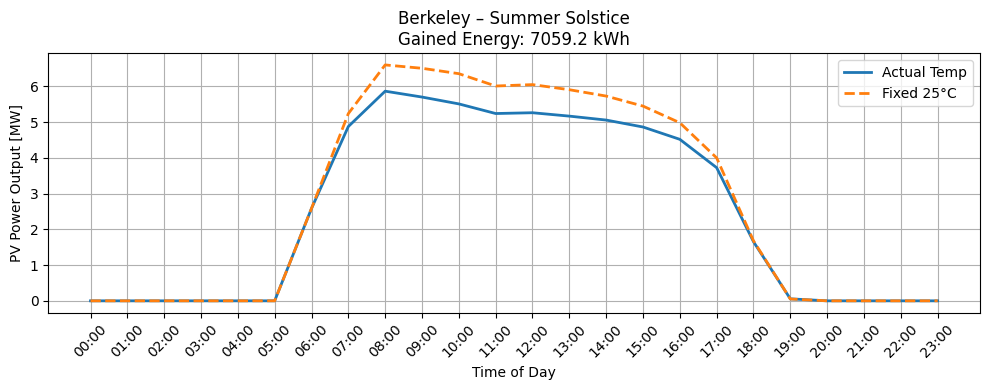

In [10]:
for name in locations:
    weather = weather_data[name]
    irr = irr_all[name]
    temp_C = cell_temp_all[name]
    temp_C.index = temp_C.index.map(lambda x: x.replace(year=2000))

    fixed_cell_temp = pd.Series(25, index=irr.index)
    lat, lon, tz = locations[name]
    alt = weather.attrs.get("altitude", 50)

    # Solar geometry
    solpos = pvlib.solarposition.get_solarposition(
        time=weather.index,
        latitude=lat,
        longitude=lon,
        altitude=alt,
        temperature=weather["temp_air"],
        pressure=weather["pressure"],
    )

    # Tracking
    tracking = pvlib.tracking.singleaxis(
        apparent_zenith=solpos['apparent_zenith'],
        apparent_azimuth=solpos['azimuth'],
        axis_tilt=0,
        axis_azimuth=180,
        max_angle=60,
        backtrack=True,
        gcr=gcr
    )
    surface_tilt = tracking['surface_tilt'].fillna(0)
    surface_azimuth = tracking['surface_azimuth'].fillna(0)

    # Optical calculations
    airmass = pvlib.atmosphere.get_relative_airmass(solpos['apparent_zenith'])
    pressure = pvlib.atmosphere.alt2pres(alt)
    am_abs = pvlib.atmosphere.get_absolute_airmass(airmass, pressure)

    aoi = pvlib.irradiance.aoi(
        surface_tilt,
        surface_azimuth,
        solpos['apparent_zenith'],
        solpos['azimuth'],
    )

    eff_irr = pvlib.pvsystem.sapm_effective_irradiance(
        irr['poa_direct'], irr['poa_diffuse'], am_abs, aoi, module
    )

    # PV power with real temperature
    dc_real = pvlib.pvsystem.sapm(eff_irr, temp_C, module)
    dc_power_real = dc_real['p_mp'] * modules_per_string * total_strings / 1e6  # MW

    # PV power with fixed temperature
    dc_fixed = pvlib.pvsystem.sapm(eff_irr, fixed_cell_temp, module)
    dc_power_fixed = dc_fixed['p_mp'] * modules_per_string * total_strings / 1e6  # MW

    # Only plot Equinox and Summer Solstice
    for label, date_str in dates.items():
        if label == 'Winter Solstice':
    # Still log result with 0 PV gain
            for r in results:
                if r["Location"] == name and r["Day"] == label:
                    r["E_PV_Gain_kWh"] = 0.0
            continue  # Skip plotting, but still record


        idx = dc_power_real.index.map(lambda x: x.replace(year=2000)).strftime('%m-%d') == date_str

        energy_real = dc_power_real[idx].sum() * 1e3  # MWh to kWh
        energy_fixed = dc_power_fixed[idx].sum() * 1e3
        delta_energy = energy_fixed - energy_real

                # Store PV energy gain for matching entry
        for r in results:
            if r["Location"] == name and r["Day"] == label:
                r["E_PV_Gain_kWh"] = delta_energy

        plt.figure(figsize=(10, 4))
        plt.plot(dc_power_real[idx].index.strftime('%H:%M'), dc_power_real[idx], label='Actual Temp', linewidth=2)
        plt.plot(dc_power_fixed[idx].index.strftime('%H:%M'), dc_power_fixed[idx], label='Fixed 25°C', linestyle='--', linewidth=2)
        plt.title(f"{name} – {label}\nGained Energy: {delta_energy:.1f} kWh")
        plt.xlabel("Time of Day")
        plt.ylabel("PV Power Output [MW]")
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


### Results Summary

For each city and date, we calculate:
- Total energy generated using actual cell temperatures
- Total energy generated assuming a fixed 25°C
- The difference between the two (ΔEnergy)

These results are visualized with time-series plots comparing the two output curves. The **gained energy** is displayed in each plot title.

---

### Key Takeaways

- **Bath**, being cooler, shows minimal gains from cooling — confirming that TEGs may be better suited there.
- **Seoul and Berkeley**, especially during summer, show notable increases in PV energy when cooled — confirming that **cooling improves panel efficiency**.
- This gives a clear basis for comparing **energy gained through cooling** versus **energy spent by the cooling system**, enabling an informed decision on viability.

Combined with TEG results, this section supports a broader analysis of passive vs active thermal management strategies for PV performance optimization.


In [11]:
# Compare strategies
summary = []
for r in results:
    if r["E_TEG_kWh"] is not None and r["E_PV_Gain_kWh"] is not None and r["E_Cooling_kWh"] is not None:
        net_cooling_gain = r["E_PV_Gain_kWh"] - r["E_Cooling_kWh"]
        winner = "Cooling" if net_cooling_gain > r["E_TEG_kWh"] else "TEG"
        summary.append({
            "Location": r["Location"],
            "Day": r["Day"],
            "TEG Energy [kWh]": round(r["E_TEG_kWh"], 2),
            "Cooling Energy [kWh]": round(r["E_Cooling_kWh"], 2),
            "PV Energy Gain [kWh]": round(r["E_PV_Gain_kWh"], 2),
            "Net Cooling Gain [kWh]": round(net_cooling_gain, 2),
            "Winner": winner
        })

# Display comparison
df_summary = pd.DataFrame(summary)
from IPython.display import display
display(df_summary)


,Location,Day,TEG Energy [kWh],Cooling Energy [kWh],PV Energy Gain [kWh],Net Cooling Gain [kWh],Winner
0,Bath,Winter Solstice,27.81,0.00,0.00,0.00,TEG
1,Bath,Equinox,1031.91,1669.91,722.33,-947.58,TEG
2,Bath,Summer Solstice,795.49,2606.38,1427.04,-1179.34,TEG
3,Seoul,Winter Solstice,482.15,0.00,0.00,0.00,TEG
4,Seoul,Equinox,1366.46,3254.17,1919.91,-1334.26,TEG
5,Seoul,Summer Solstice,1667.38,9564.59,5714.03,-3850.56,TEG
6,Berkeley,Winter Solstice,13.44,0.00,0.00,0.00,TEG
7,Berkeley,Equinox,1607.33,4171.15,2897.93,-1273.22,TEG
8,Berkeley,Summer Solstice,2205.97,9853.66,7059.18,-2794.48,TEG


## Comparative Analysis: TEG vs. Active Cooling Strategy

### Key Takeaways

- **TEG outperforms cooling in every case**, including high-irradiance summer days.  
- **Net cooling gain is consistently negative**, suggesting that the energy required to cool the panels outweighs the benefit from PV efficiency gains.
- Even in **Berkeley**, where irradiance is highest, **TEG delivers more usable energy** than cooling because it requires more energy to cool the hotter panels.
- **Winter solstice days** show zero net cooling gain, as expected, due to minimal temperature difference and low irradiance — yet TEGs still produce modest energy.

Thermoelectric generators offer a more energy-efficient strategy than active cooling across all evaluated climates and seasonal conditions. This suggests that in locations where passive or low-maintenance thermal recovery is preferred, **TEGs present a more viable solution** than electrically driven cooling systems simply due to the fact that active cooling systems require great amount of energy. This is especially true because we were targetting all the way for the optimal temperature of 25°C. 


---

## Improving Performance: Theoretical Cooling Scenario

To explore whether active cooling could ever outperform thermoelectric generators (TEGs), we simulated a **theoretical minimum-power cooling case** under the most optimistic assumptions:

- **Heat transfer coefficient:** $h = 1\ \text{W/m}^2\cdot\text{K}$  
- **Coefficient of performance (COP):** 12

These values were chosen to push the **lower bounds of power consumption** for the cooling system. However, it's important to note:

### Realism of Assumptions

- **$h = 1$ W/m²·K** is **extremely low**, suggesting near-perfect insulation or highly localized cooling. In real outdoor PV systems, even passive systems (e.g. natural convection + radiation) usually experience $h$ values between **5–15 W/m²·K**, and **active air or water cooling systems** often operate at even higher values. Reaching $h = 1$ would require impractical or highly specialized setups that are not viable at scale.

- **COP = 12** is **near the thermodynamic limit** of current refrigeration systems. Typical COP values for real-world PV cooling units (e.g., air conditioning or Peltier-based systems) fall in the **2–6 range**. Achieving COP = 12 would require:
  - Very small temperature differentials
  - Near-reversible heat exchange
  - Idealized conditions not found in dynamic outdoor environments


In [12]:
# Theoretical cooling parameters
h_cool_theoretical = 1.0
COP_theoretical = 12.0

for r in results:
    name = r["Location"]
    label = r["Day"]
    
    temp_C = cell_temp_all[name].copy()
    temp_C.index = temp_C.index.map(lambda x: x.replace(year=2000))
    date_str = dates[label]  # 🌟 this is the fix
    T_cell = temp_C[temp_C.index.strftime('%m-%d') == date_str]
    
    delta_T = (T_cell - target_temp).clip(lower=0)
    Q_per_panel = A_panel * h_cool_theoretical * delta_T
    P_cool = Q_per_panel / COP_theoretical * total_strings * modules_per_string
    E_cool_theoretical = P_cool.sum() / 1000  # kWh

    if r["E_PV_Gain_kWh"] is not None:
        net_gain_theoretical = r["E_PV_Gain_kWh"] - E_cool_theoretical
    else:
        net_gain_theoretical = 0.0

    r["E_Cooling_Theoretical_kWh"] = round(E_cool_theoretical, 2)
    r["Net_Theoretical_Gain_kWh"] = round(net_gain_theoretical, 2)
    r["Winner_Theoretical"] = "Cooling" if net_gain_theoretical > r["E_TEG_kWh"] else "TEG"

    print(f"{name} – {label}: Theoretical Cooling Energy = {E_cool_theoretical:.2f} kWh")


Bath – Winter Solstice: Theoretical Cooling Energy = 0.00 kWh
Bath – Equinox: Theoretical Cooling Energy = 166.99 kWh
Bath – Summer Solstice: Theoretical Cooling Energy = 260.64 kWh
Seoul – Winter Solstice: Theoretical Cooling Energy = 0.00 kWh
Seoul – Equinox: Theoretical Cooling Energy = 325.42 kWh
Seoul – Summer Solstice: Theoretical Cooling Energy = 956.46 kWh
Berkeley – Winter Solstice: Theoretical Cooling Energy = 0.00 kWh
Berkeley – Equinox: Theoretical Cooling Energy = 417.11 kWh
Berkeley – Summer Solstice: Theoretical Cooling Energy = 985.37 kWh


In [13]:
# Extract relevant values
improvement_results = []
for r in results:
    improvement_results.append({
        "Location": r["Location"],
        "Day": r["Day"],
        "TEG Energy [kWh]": round(r["E_TEG_kWh"], 2),
        "Net Cooling Gain (Original) [kWh]": round(r["E_PV_Gain_kWh"] - r["E_Cooling_kWh"], 2) if r["E_PV_Gain_kWh"] is not None else None,
        "Net Cooling Gain (Theoretical) [kWh]": r["Net_Theoretical_Gain_kWh"],
        "Winner (Theoretical Case)": r["Winner_Theoretical"]
    })

df_improved = pd.DataFrame(improvement_results)
from IPython.display import display
display(df_improved)


,Location,Day,TEG Energy [kWh],Net Cooling Gain (Original) [kWh],Net Cooling Gain (Theoretical) [kWh],Winner (Theoretical Case)
0,Bath,Winter Solstice,27.81,0.00,0.00,TEG
1,Bath,Equinox,1031.91,-947.58,555.34,TEG
2,Bath,Summer Solstice,795.49,-1179.34,1166.40,Cooling
3,Seoul,Winter Solstice,482.15,0.00,0.00,TEG
4,Seoul,Equinox,1366.46,-1334.26,1594.50,Cooling
5,Seoul,Summer Solstice,1667.38,-3850.56,4757.57,Cooling
6,Berkeley,Winter Solstice,13.44,0.00,0.00,TEG
7,Berkeley,Equinox,1607.33,-1273.22,2480.81,Cooling
8,Berkeley,Summer Solstice,2205.97,-2794.48,6073.81,Cooling


## Final Analysis: Can Cooling Beat TEG with Ideal Conditions?

### Interpretation

- Under **realistic conditions**, **cooling consistently underperforms** due to the energy cost of maintaining optimal cell temperature.
- However, when modeled under **theoretical minimum-power conditions** ($h = 1\ \text{W/m}^2\cdot\text{K}$, $\text{COP} = 12$), **cooling becomes viable** — even superior — in high-irradiance environments like **Berkeley summer** and **Seoul summer**.
- The **turning point** appears during the **Summer Solstice**, where improved cooling surpasses TEG output in **all three locations**.
- In **low-irradiance cases** like the **Winter Solstice**, neither TEG nor cooling yields significant output, and **TEGs remain more energy-efficient**.

### Why This Matters

With ideal parameters, **cooling systems could surpass TEGs**, especially in sunny regions and during peak summer. However, such parameters push the limits of current technology. Real-world deployment would still favor TEGs unless **substantial improvements in cooling technology** (or system integration) are achieved.

Beyond energy gains, maintaining cooler panel temperatures has long-term reliability benefits. Active cooling can help reduce thermal degradation, lower maintenance costs, and extend the operational lifespan of PV modules — advantages not captured in short-term energy output but critical for overall system viability.

By running this simulation, we aren't suggesting that such a cooling system is feasible — rather, we are testing **how much performance must improve** before active cooling becomes competitive with TEGs.

In most cases, even under these idealized assumptions, **TEGs still outperform cooling**. This reinforces the robustness and simplicity of TEG-based recovery, especially in climates where cooling demand is high as seen in Bath where even on equinox TEG outperformed cooling.


---

## Conclusions

Our analysis compared thermoelectric generators (TEGs) and active cooling strategies for enhancing photovoltaic (PV) performance across three cities and seasonal conditions. Under realistic parameters, TEGs consistently outperformed cooling systems, as the energy consumed for cooling exceeded the gains in PV efficiency. To explore the potential of future technologies, we simulated a best-case cooling scenario using highly optimistic assumptions. While this idealized setup allowed cooling to outperform TEGs during high-irradiance summer days, TEGs remained superior in cooler, lower-radiance conditions. These findings suggest that while advanced cooling could one day compete with or complement TEGs, current implementations favor passive heat recovery. Ultimately, system choice should consider local climate, maintenance demands, and scalability. TEGs offer a low-maintenance, climate-resilient solution, whereas active cooling may become viable with continued innovation in energy-efficient thermal management. Future investigations may also incorporate cost considerations and examine the tradeoffs between the energy gained per additional degree Celsius through TEGs versus that gained via passive or hybrid cooling approaches, in order to identify the most cost-effective thermal strategy for a given environment.
